In [1]:
source('/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/scripts/MS0_Libraries.r')

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/miniconda3/envs/my_jupyter_env/lib/R/library/"


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘tibble’ was built under R version 4.3.3”
Warning message:
“package ‘purrr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.3”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
Warning message:
“package ‘lubridate’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘backports’ w

In [2]:
plate_names= c("plate_1", "plate_2", "plate_3", "plate_4", "plate_5", "plate_6", "plate_7", "plate_8", "plate_9", "plate_10", "plate_11", "plate_12")
plates = list()
for (i in plate_names){
    plates[[i]] = readRDS(paste0("/ictstr01/home/icb/bhavishya.nelakuditi/bulk_seq/new_counts/cycle_cohort_metadata/processed/",i,"_processed.rds"))
    }

In [3]:
head(plates[["plate_1"]])

,ENSEMBL,LCLC100154,LCLC200028,LCLC200067,LCSC100029,LCLC400339,LCSC100041,LCLC400152,LCLC300141,LCLC200053,⋯,LCLC200125,LCLC300030,LCLC200344,LCLC200346,LCSC200063,LCLC100133,LCLC200048,LCLC300156,external_gene_name,description
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,ENSG00000000003,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,TSPAN6,tetraspanin 6 [Source:HGNC Symbol;Acc:HGNC:11858]
2,ENSG00000000419,9,6,14,2,9,4,3,4,8,⋯,2,8,2,7,9,4,2,1,DPM1,"dolichyl-phosphate mannosyltransferase subunit 1, catalytic [Source:HGNC Symbol;Acc:HGNC:3005]"
3,ENSG00000000457,4,5,5,3,1,5,6,0,7,⋯,1,0,0,6,3,0,1,0,SCYL3,SCY1 like pseudokinase 3 [Source:HGNC Symbol;Acc:HGNC:19285]
4,ENSG00000000460,0,1,1,0,0,0,0,0,4,⋯,0,0,1,1,0,1,0,0,FIRRM,FIGNL1 interacting regulator of recombination and mitosis [Source:HGNC Symbol;Acc:HGNC:25565]
5,ENSG00000000938,59,23,65,48,49,61,45,37,47,⋯,42,37,24,67,75,36,38,16,FGR,"FGR proto-oncogene, Src family tyrosine kinase [Source:HGNC Symbol;Acc:HGNC:3697]"
6,ENSG00000000971,0,0,1,0,0,0,0,0,1,⋯,0,0,0,1,0,0,0,0,CFH,complement factor H [Source:HGNC Symbol;Acc:HGNC:4883]


In [4]:
# Assuming each data frame in the 'plates' list has an ENSEMBL column
merged_data <- Reduce(function(x, y) merge(x, y, by = "ENSEMBL", all = TRUE), plates)

Warning message in merge.data.frame(x, y, by = "ENSEMBL", all = TRUE):
“column names ‘external_gene_name.x’, ‘description.x’, ‘external_gene_name.y’, ‘description.y’ are duplicated in the result”
Warning message in merge.data.frame(x, y, by = "ENSEMBL", all = TRUE):
“column names ‘external_gene_name.x’, ‘description.x’, ‘external_gene_name.y’, ‘description.y’ are duplicated in the result”
Warning message in merge.data.frame(x, y, by = "ENSEMBL", all = TRUE):
“column names ‘external_gene_name.x’, ‘description.x’, ‘external_gene_name.y’, ‘description.y’, ‘external_gene_name.x’, ‘description.x’, ‘external_gene_name.y’, ‘description.y’ are duplicated in the result”
Warning message in merge.data.frame(x, y, by = "ENSEMBL", all = TRUE):
“column names ‘external_gene_name.x’, ‘description.x’, ‘external_gene_name.y’, ‘description.y’, ‘external_gene_name.x’, ‘description.x’, ‘external_gene_name.y’, ‘description.y’ are duplicated in the result”
Warning message in merge.data.frame(x, y, by = "ENSE

In [5]:
# If you already have merged_data with duplicates
# Get unique column names (excluding those ending with .x, .y, etc.)
unique_cols <- unique(gsub("\\.[xy].*$", "", names(merged_data)))

# Keep only the first occurrence of each duplicated column
cols_to_keep <- c()
for(col in unique_cols) {
  matching_cols <- grep(paste0("^", col, "($|\\.)"), names(merged_data), value = TRUE)
  cols_to_keep <- c(cols_to_keep, matching_cols[1])
}

# Create the cleaned data frame with only unique columns
cleaned_data <- merged_data[, cols_to_keep, drop = FALSE]

In [6]:
head(cleaned_data)

,ENSEMBL,LCLC100154,LCLC200028,LCLC200067,LCSC100029,LCLC400339,LCSC100041,LCLC400152,LCLC300141,LCLC200053,⋯,LCLC200253,LCLC200351,LCLC100254,LCLC200252,LCLC100251,LCLC100252,LCLC100253,LCLC200255,LCLC100256,LCLC300253
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ENSG00000000003,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,ENSG00000000419,9,6,14,2,9,4,3,4,8,⋯,16,18,15,26,28,41,25,26,32,23
3,ENSG00000000457,4,5,5,3,1,5,6,0,7,⋯,7,6,1,8,6,7,6,5,15,8
4,ENSG00000000460,0,1,1,0,0,0,0,0,4,⋯,0,0,0,1,1,1,1,2,2,0
5,ENSG00000000938,59,23,65,48,49,61,45,37,47,⋯,89,147,52,103,158,148,155,76,182,135
6,ENSG00000000971,0,0,1,0,0,0,0,0,1,⋯,1,0,0,0,2,0,0,0,1,1


In [7]:
colnames(cleaned_data)

[1] "ENSEMBL"              "LCLC100154"           "LCLC200028"          
   [4] "LCLC200067"           "LCSC100029"           "LCLC400339"          
   [7] "LCSC100041"           "LCLC400152"           "LCLC300141"          
  [10] "LCLC200053"           "LCLC100029"           "LCLC100139"          
  [13] "LCLC400125"           "LCLC100210"           "LCSC200036"          
  [16] "LCLC100058"           "LCLC100015"           "LCSC300063"          
  [19] "LCLC300202"           "LCLC200156"           "LCLC200338"          
  [22] "LCSC300065"           "LCLC200072"           "LCSC200070"          
  [25] "LCLC200020"           "LCLC400062"           "LCLC200065"          
  [28] "LCLC200199"           "LCLC300186"           "LCLC100061"          
  [31] "LCLC400144"           "LCSC200035"           "LCLC400193"          
  [34] "LCLC300196"           "LCLC300073"           "LCLC200189"          
  [37] "LCLC400182"           "LCLC400345"           "LCLC100088"          
  [40] "LCLC100146"           "LCLC300191"           "LCLC300213"          
  [43] "LCSC100125"           "LCLC200128"           "LCSC300001"          
  [46] "LCLC400142"           "LCLC400016"           "LCLC200206"          
  [49] "LCLC300183"           "LCLC300132"           "LCLC400165"          
  [52] "LCLC300010"           "LCLC200032"           "LCLC300207"          
  [55] "LCLC100342"           "LCLC200162"           "LCLC200336"          
  [58] "LCSC100010"           "LCLC400336"           "LCLC300145"          
  [61] "LCLC200342"           "LCLC100156"           "LCLC100013"          
  [64] "LCLC300039"           "LCLC100012"           "LCLC400080"          
  [67] "LCLC400212"           "LCLC300220"           "LCLC300137"          
  [70] "LCLC300003"           "LCLC100028"           "LCLC100150"          
  [73] "LCLC300153"           "LCLC200161"           "LCLC400085"          
  [76] "LCLC100199"           "LCLC400058"           "LCSC300056"          
  [79] "LCLC400256"           "LCSC200026"           "LCLC200088"          
  [82] "LCSC100031"           "LCLC200201"           "LCSC300072"          
  [85] "LCLC100202"           "LCLC400201"           "LCLC400078"          
  [88] "LCSC200017"           "LCLC300152"           "LCLC200125"          
  [91] "LCLC300030"           "LCLC200344"           "LCLC200346"          
  [94] "LCSC200063"           "LCLC100133"           "LCLC200048"          
  [97] "LCLC300156"           "external_gene_name.x" "description.x"       
 [100] "LCSC100022"           "LCSC100007"           "LCLC300038"          
 [103] "LCLC100043"           "LCLC200216"           "LCLC300046"          
 [106] "LCLC200211"           "LCLC100238"           "LCLC300034"          
 [109] "LCLC100040"           "LCLC200036"           "LCLC200045"          
 [112] "LCLC200219"           "LCLC100034"           "LCLC400218"          
 [115] "LCLC100039"           "LCLC200222"           "LCLC300219"          
 [118] "LCLC100045"           "LCLC300211"           "LCLC200212"          
 [121] "LCLC100212"           "LCLC200214"           "LCLC200034"          
 [124] "LCLC200035"           "LCLC300037"           "LCLC400039"          
 [127] "LCSC200006"           "LCLC300217"           "LCLC300036"          
 [130] "LCSC200020"           "LCLC200042"           "LCSC100003"          
 [133] "LCLC300215"           "LCLC100222"           "LCSC100043"          
 [136] "LCLC200043"           "LCLC400222"           "LCSC200011"          
 [139] "LCLC300208"           "LCSC100020"           "LCLC100035"          
 [142] "LCLC300216"           "LCLC400046"           "LCLC400209"          
 [145] "LCLC300210"           "LCLC400221"           "LCLC200220"          
 [148] "LCLC100215"           "LCLC200033"           "LCLC100047"          
 [151] "LCLC100221"           "LCLC100042"           "LCLC300214"          
 [154] "LCLC100214"           "LCLC300209"           "LCLC200215"          
 [157] "LCLC200044"           "LCSC200016"         

In [8]:
# First, remove rows where external_gene_name.x is NA
cleaned_data <- cleaned_data[!is.na(cleaned_data$external_gene_name.x), ]

# Then handle the duplicate row names issue
rownames(cleaned_data) <- make.unique(cleaned_data$external_gene_name.x)

In [9]:
nrow(cleaned_data)

[1] 22162

In [10]:
head(cleaned_data)

,ENSEMBL,LCLC100154,LCLC200028,LCLC200067,LCSC100029,LCLC400339,LCSC100041,LCLC400152,LCLC300141,LCLC200053,⋯,LCLC200253,LCLC200351,LCLC100254,LCLC200252,LCLC100251,LCLC100252,LCLC100253,LCLC200255,LCLC100256,LCLC300253
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TSPAN6,ENSG00000000003,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
DPM1,ENSG00000000419,9,6,14,2,9,4,3,4,8,⋯,16,18,15,26,28,41,25,26,32,23
SCYL3,ENSG00000000457,4,5,5,3,1,5,6,0,7,⋯,7,6,1,8,6,7,6,5,15,8
FIRRM,ENSG00000000460,0,1,1,0,0,0,0,0,4,⋯,0,0,0,1,1,1,1,2,2,0
FGR,ENSG00000000938,59,23,65,48,49,61,45,37,47,⋯,89,147,52,103,158,148,155,76,182,135
CFH,ENSG00000000971,0,0,1,0,0,0,0,0,1,⋯,1,0,0,0,2,0,0,0,1,1


In [11]:
# Remove specific columns but keep ENSEMBL
dataset <- cleaned_data[, !names(cleaned_data) %in% c("description.x", "external_gene_name.x","ENSEMBL"), drop = FALSE]

In [12]:
head(dataset)

,LCLC100154,LCLC200028,LCLC200067,LCSC100029,LCLC400339,LCSC100041,LCLC400152,LCLC300141,LCLC200053,LCLC100029,⋯,LCLC200253,LCLC200351,LCLC100254,LCLC200252,LCLC100251,LCLC100252,LCLC100253,LCLC200255,LCLC100256,LCLC300253
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TSPAN6,1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
DPM1,9,6,14,2,9,4,3,4,8,7,⋯,16,18,15,26,28,41,25,26,32,23
SCYL3,4,5,5,3,1,5,6,0,7,8,⋯,7,6,1,8,6,7,6,5,15,8
FIRRM,0,1,1,0,0,0,0,0,4,0,⋯,0,0,0,1,1,1,1,2,2,0
FGR,59,23,65,48,49,61,45,37,47,26,⋯,89,147,52,103,158,148,155,76,182,135
CFH,0,0,1,0,0,0,0,0,1,0,⋯,1,0,0,0,2,0,0,0,1,1


In [13]:
nrow(dataset)

[1] 22162

In [17]:
sample_metadata = read.csv("/ictstr01/home/icb/bhavishya.nelakuditi/bulk_seq/new_counts/cycle_cohort_metadata/outputs/all_plates_mapping_processed_renamed.csv")

In [18]:
head(sample_metadata)

,plate,sample_ID,barcode,condition,tp,Patient,Day
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>
1,plate 1,LCLC400142,CTGGACTAACAA,UKE-HF,4,142,Discharge
2,plate 1,LCLC200201,TCGGCTGTCCAA,UKE-HF,2,201,Tag 3
3,plate 1,LCLC300153,GTTGTGCTCCAA,UKE-HF,3,153,Tag 5
4,plate 1,LCLC200156,AGCCATAGTAGA,UKE-HF,2,156,Tag 3
5,plate 1,LCSC100031,TCGAGTCTGGCA,UKE-CS,1,31,Baseline
6,plate 1,LCLC300137,GTATGCTTCCTA,UKE-HF,3,137,Tag 5


In [19]:
rownames(sample_metadata) = sample_metadata$sample_ID
colsd = colnames(dataset)
sample_metadata = sample_metadata[colsd, ]
head(sample_metadata)

,plate,sample_ID,barcode,condition,tp,Patient,Day
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>
LCLC100154,plate 1,LCLC100154,AACAGCGCCATG,UKE-HF,1,154,Baseline
LCLC200028,plate 1,LCLC200028,AACAGGTTCCAA,UKE-HF,2,28,Tag 3
LCLC200067,plate 1,LCLC200067,AACCGGTGATAG,UKE-HF,2,67,Tag 3
LCSC100029,plate 1,LCSC100029,AACGCCAGCGAA,UKE-CS,1,29,Baseline
LCLC400339,plate 1,LCLC400339,AACGTAACGCTG,UKE-HF,4,339,Discharge
LCSC100041,plate 1,LCSC100041,AAGCCTCAGTCC,UKE-CS,1,41,Baseline


In [17]:
genes = cleaned_data[, names(cleaned_data) %in% c("description.x", "external_gene_name.x","ENSEMBL")]
head(genes)

,ENSEMBL,external_gene_name.x,description.x
,<chr>,<chr>,<chr>
TSPAN6,ENSG00000000003,TSPAN6,tetraspanin 6 [Source:HGNC Symbol;Acc:HGNC:11858]
DPM1,ENSG00000000419,DPM1,"dolichyl-phosphate mannosyltransferase subunit 1, catalytic [Source:HGNC Symbol;Acc:HGNC:3005]"
SCYL3,ENSG00000000457,SCYL3,SCY1 like pseudokinase 3 [Source:HGNC Symbol;Acc:HGNC:19285]
FIRRM,ENSG00000000460,FIRRM,FIGNL1 interacting regulator of recombination and mitosis [Source:HGNC Symbol;Acc:HGNC:25565]
FGR,ENSG00000000938,FGR,"FGR proto-oncogene, Src family tyrosine kinase [Source:HGNC Symbol;Acc:HGNC:3697]"
CFH,ENSG00000000971,CFH,complement factor H [Source:HGNC Symbol;Acc:HGNC:4883]


In [18]:
dataset_clean <- dataset
dataset_clean[is.na(dataset_clean)] <- 0

In [19]:
head(dataset_clean)

,LCLC100001,LCLC100002,LCLC100003,LCLC100004,LCLC100005,LCLC100006,LCLC100007,LCLC100008,LCLC100009,LCLC100010,⋯,LCSC300057,LCSC300061,LCSC300063,LCSC300065,LCSC300066,LCSC300068,LCSC300069,LCSC300070,LCSC300072,LCSC300073
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
TSPAN6,0,0,0,1,0,1,0,0,0,0,⋯,0,0,0,0,0,0,2,0,0,2
DPM1,13,7,26,12,12,8,9,13,13,14,⋯,32,5,3,7,19,18,22,11,14,25
SCYL3,14,2,17,6,8,3,4,11,10,6,⋯,5,4,7,3,5,5,7,5,6,4
FIRRM,3,0,1,1,0,1,0,1,2,1,⋯,4,0,2,4,0,1,0,1,1,2
FGR,86,73,248,74,53,50,48,105,48,56,⋯,315,36,45,38,39,131,74,64,149,140
CFH,0,0,3,1,0,0,1,0,2,0,⋯,0,1,0,2,1,0,3,0,0,0


In [20]:
genes$external_gene_name.x

[1] "TSPAN6"                    "DPM1"                     
    [3] "SCYL3"                     "FIRRM"                    
    [5] "FGR"                       "CFH"                      
    [7] "FUCA2"                     "GCLC"                     
    [9] "NFYA"                      "STPG1"                    
   [11] "NIPAL3"                    "LAS1L"                    
   [13] "ENPP4"                     "ANKIB1"                   
   [15] "CYP51A1"                   "KRIT1"                    
   [17] "RAD52"                     "BAD"                      
   [19] "LAP3"                      "CD99"                     
   [21] "HS3ST1"                    "AOC1"                     
   [23] "WNT16"                     "MAD1L1"                   
   [25] "LASP1"                     "SNX11"                    
   [27] "TMEM176A"                  "M6PR"                     
   [29] "KLHL13"                    "CYP26B1"                  
   [31] "ICA1"                      "DBNDD1"                   
   [33] "ALS2"                      "CASP10"                   
   [35] "CFLAR"                     "TFPI"                     
   [37] "NDUFAF7"                   "RBM5"                     
   [39] "MTMR7"                     "ARF5"                     
   [41] "SARM1"                     "POLDIP2"                  
   [43] "PLXND1"                    "AK2"                      
   [45] "CD38"                      "FKBP4"                    
   [47] "KDM1A"                     "RBM6"                     
   [49] "CAMKK1"                    "RECQL"                    
   [51] "VPS50"                     "HSPB6"                    
   [53] "ARHGAP33"                  "NDUFAB1"                  
   [55] "PDK4"                      "SLC22A16"                 
   [57] "ZMYND10"                   "ABCB5"                    
   [59] "SLC25A13"                  "ST7"                      
   [61] "CDC27"                     "SLC4A1"                   
   [63] "CALCR"                     "HCCS"                     
   [65] "DVL2"                      "PRSS22"                   
   [67] "UPF1"                      "SKAP2"                    
   [69] "SLC25A5"                   "MCUB"                     
   [71] "POLR2J"                    "DHX33"                    
   [73] "MEOX1"                     "THSD7A"                   
   [75] "LIG3"                      "RPAP3"                    
   [77] "ACSM3"                     "REXO5"                    
   [79] "CIAPIN1"                   "SPPL2B"                   
   [81] "ATOSB"                     "COPZ2"                    
   [83] "PRKAR2B"                   "MSL3"                     
   [85] "CREBBP"                    "TSPOAP1"                  
   [87] "MPO"                       "GCFC2"                    
   [89] "WDR54"                     "CROT"                     
   [91] "ABCB4"                     "KMT2E"                    
   [93] "RHBDD2"                    "SOX8"                     
   [95] "IBTK"                      "ZNF195"                   
   [97] "MYCBP2"                    "FBXL3"                    
   [99] "ITGAL"                     "PDK2"                     
  [101] "ITGA3"                     "ZFX"                      
  [103] "LAMP2"                     "ITGA2B"                   
  [105] "GDE1"                      "REX1BD"                   
  [107] "CRLF1"                     "OSBPL7"                   
  [109] "TMEM98"                    "YBX2"                     
  [111] "MAP3K14"                   "ABCC8"                    
  [113] "TMEM132A"                  "AP2B1"                    
  [115] "ZNF263"                    "SPATA20"                  
  [117] "TNFRSF12A"                 "MAP3K9"                   
  [119] "RALA"                      "BAIAP2L1"                 
  [121] "KDM7A"                     "ETV1"                     
  [123] "AGK"                       "ALDH3B1"                  
  [125] "TTC22"                     

In [24]:
cell_type_agnostic_genes = read.csv("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/input_data/cell_type_agnostic.csv")
head(cell_type_agnostic_genes)

,AL627309.1,AL627309.5,LINC01409,LINC01128,LINC00115,SAMD11,NOC2L,KLHL17,HES4,ISG15,⋯,AL450263.1,AC090531.1,AL132711.1,AC093610.1,C6orf118,LINC01978,LINC01879,AC008687.4,AC007731.2,sample_id
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,0.0000000000,0.000454821,0.008075295,0.009362473,0.0013644630,0.0000000000,0.005989958,0.000454821,0.0216084426,0.09654464,⋯,0,0,0,0,0,0,0,0,0,KS35.2
2,0.0016721648,0.001055019,0.011167332,0.012660222,0.0021100371,0.0000000000,0.007385130,0.000000000,0.0010550185,0.02928192,⋯,0,0,0,0,0,0,0,0,0,KS32.1
3,0.0014970781,0.000000000,0.003742695,0.009858203,0.0014970781,0.0029941563,0.009731008,0.001497078,0.0007485391,0.04148154,⋯,0,0,0,0,0,0,0,0,0,KS35.1
4,0.0000000000,0.000000000,0.006887641,0.006887641,0.0028708707,0.0006261492,0.005009194,0.001252298,0.0053754675,0.06794433,⋯,0,0,0,0,0,0,0,0,0,KS4.2
5,0.0004099037,0.000000000,0.006218209,0.008198074,0.0008198074,0.0000000000,0.005738652,0.000000000,0.0077881706,0.03078161,⋯,0,0,0,0,0,0,0,0,0,KS22.1
6,0.0000000000,0.001752585,0.007448484,0.007448484,0.0017525845,0.0000000000,0.009201069,0.001314438,0.0028851758,0.09508770,⋯,0,0,0,0,0,0,0,0,0,KS16.2


In [25]:
# Get all column names except the last one
cell_type_agnostic_genes = colnames(cell_type_agnostic_genes)[-ncol(cell_type_agnostic_genes)]
cell_type_agnostic_genes
length(cell_type_agnostic_genes)

[1] "AL627309.1"        "AL627309.5"        "LINC01409"        
    [4] "LINC01128"         "LINC00115"         "SAMD11"           
    [7] "NOC2L"             "KLHL17"            "HES4"             
   [10] "ISG15"             "AL645608.1"        "AGRN"             
   [13] "C1orf159"          "AL390719.3"        "TTLL10"           
   [16] "TNFRSF18"          "TNFRSF4"           "SDF4"             
   [19] "B3GALT6"           "AL162741.1"        "UBE2J2"           
   [22] "SCNN1D"            "ACAP3"             "PUSL1"            
   [25] "INTS11"            "CPTP"              "TAS1R3"           
   [28] "DVL1"              "AURKAIP1"          "CCNL2"            
   [31] "MRPL20.AS1"        "MRPL20"            "AL391244.2"       
   [34] "ATAD3C"            "ATAD3B"            "ATAD3A"           
   [37] "SSU72"             "AL645728.1"        "FNDC10"           
   [40] "AL691432.4"        "AL691432.2"        "MIB2"             
   [43] "MMP23B"            "CDK11B"            "FO704657.1"       
   [46] "SLC35E2B"          "CDK11A"            "SLC35E2A"         
   [49] "NADK"              "GNB1"              "TMEM52"           
   [52] "PRKCZ"             "AL590822.2"        "FAAP20"           
   [55] "AL590822.1"        "SKI"               "AL590822.3"       
   [58] "MORN1"             "AL589739.1"        "RER1"             
   [61] "PEX10"             "PLCH2"             "PANK4"            
   [64] "AL139246.5"        "TNFRSF14.AS1"      "TNFRSF14"         
   [67] "AL139246.3"        "PRXL2B"            "MMEL1"            
   [70] "TTC34"             "PRDM16"            "AL354743.2"       
   [73] "MEGF6"             "TPRG1L"            "WRAP73"           
   [76] "TP73"              "SMIM1"             "LRRC47"           
   [79] "CEP104"            "DFFB"              "C1orf174"         
   [82] "LINC01134"         "AJAP1"             "AL365255.1"       
   [85] "NPHP4"             "KCNAB2"            "RPL22"            
   [88] "ICMT"              "GPR153"            "ACOT7"            
   [91] "AL031848.2"        "ESPN"              "TNFRSF25"         
   [94] "PLEKHG5"           "NOL9"              "TAS1R1"           
   [97] "ZBTB48"            "KLHL21"            "PHF13"            
  [100] "THAP3"             "DNAJC11"           "CAMTA1.DT"        
  [103] "CAMTA1"            "VAMP3"             "PER3"             
  [106] "Z98884.1"          "TNFRSF9"           "PARK7"            
  [109] "AL034417.4"        "AL034417.3"        "ERRFI1"           
  [112] "AL034417.2"        "LINC01714"         "AL358876.2"       
  [115] "SLC45A1"           "RERE"              "ENO1"             
  [118] "ENO1.AS1"          "CA6"               "SLC2A5"           
  [121] "GPR157"            "MIR34AHG"          "H6PD"             
  [124] "SPSB1"             "LINC02606"         "SLC25A33"         
  [127] "TMEM201"           "PIK3CD"            "PIK3CD.AS2"       
  [130] "CLSTN1"            "CTNNBIP1"          "AL357140.4"       
  [133] "LZIC"              "NMNAT1"            "RBP7"             
  [136] "UBE4B"             "KIF1B"             "AL139424.3"       
  [139] "PGD"               "CENPS"             "DFFA"             
  [142] "PEX14"             "CASZ1"             "AL139423.1"       
  [145] "TARDBP"            "MASP2"             "AL109811.2"       
  [148] "SRM"               "EXOSC10"           "AL109811.1"       
  [151] "MTOR"              "MTOR.AS1"          "UBIAD1"           
  [154] "DISP3"             "FBXO2"             "FBXO44"           
  [157] "FBXO6"             "MAD2L2"            "DRAXIN"           
  [160] "AGTRAP"            "C1orf167"          "MTHFR"            
  [163] "CLCN6"             "NPPA"              "AL021155.5"       
  [166] "KIAA2013"          "PLOD1"             "MFN2"             
  [169] "MIIP"              "TNFRSF8"           "TNFRSF1B"         
  [172] "VPS13D"            "DHRS3"             "HNRNPCL1"         
  [175] "PDPN"              "PRDM2"             "KAZN"      

[1] 26795

In [26]:
common_genes = intersect(rownames(dataset_clean), cell_type_agnostic_genes)
length(common_genes)

[1] 15259

In [27]:
# Apply the filter to keep only genes with rowSums > 106
filtered_dataset <- dataset_clean[common_genes, ]

# Check dimensions to see how many genes were retained
dim(dataset_clean)  # Original dimensions
dim(filtered_dataset)  # New dimensions



[1] 22162  1056

[1] 15259  1056

In [23]:
library(edgeR)

Warning message:
“package ‘edgeR’ was built under R version 4.3.3”
Loading required package: limma

Warning message:
“package ‘limma’ was built under R version 4.3.3”


In [25]:
genes = genes[rownames(filtered_dataset), ]

In [26]:
dge <- DGEList(counts = filtered_dataset, 
               genes = genes,
               samples = sample_metadata,
               remove.zeros = TRUE) %>%  
  calcNormFactors(method = "TMM")


Removing 7 rows with all zero counts



In [27]:
dge

,LCLC100001,LCLC100002,LCLC100003,LCLC100004,LCLC100005,LCLC100006,LCLC100007,LCLC100008,LCLC100009,LCLC100010,⋯,LCSC300057,LCSC300061,LCSC300063,LCSC300065,LCSC300066,LCSC300068,LCSC300069,LCSC300070,LCSC300072,LCSC300073
TSPAN6,0,0,0,1,0,1,0,0,0,0,⋯,0,0,0,0,0,0,2,0,0,2
DPM1,13,7,26,12,12,8,9,13,13,14,⋯,32,5,3,7,19,18,22,11,14,25
SCYL3,14,2,17,6,8,3,4,11,10,6,⋯,5,4,7,3,5,5,7,5,6,4
FIRRM,3,0,1,1,0,1,0,1,2,1,⋯,4,0,2,4,0,1,0,1,1,2
FGR,86,73,248,74,53,50,48,105,48,56,⋯,315,36,45,38,39,131,74,64,149,140
CFH,0,0,3,1,0,0,1,0,2,0,⋯,0,1,0,2,1,0,3,0,0,0
FUCA2,5,4,10,2,2,1,5,12,2,7,⋯,7,0,4,1,5,4,11,10,6,10
GCLC,10,16,6,13,7,9,32,23,14,9,⋯,24,4,3,10,22,168,3,2,3,8
NFYA,4,3,4,8,1,3,3,8,6,5,⋯,6,1,2,4,4,9,4,1,8,2
STPG1,2,0,3,0,3,0,0,0,0,0,⋯,0,0,0,0,1,2,0,0,2,0


In [32]:
library_size_plot <- dge$samples %>%
  ggplot(aes(x = sample_ID, y = lib.size, fill = condition)) +
  geom_bar(stat = "identity") +
  labs(y = "Library size (total number of mapped and quantified reads)",
       x = "Sample", fill = "condition") +
  coord_flip() +
  # Add this theme element to make text smaller and adjust margins
  theme(
    axis.text.y = element_text(size = 1.5),  # Smaller text size for y-axis (sample IDs)
    plot.margin = margin(r = 300, unit = "pt")  # Add right margin to make space
  )

# Save with larger dimensions to accommodate all sample IDs
ggsave("dge_obj_new/library_size_plot.pdf", library_size_plot, width = 12, height = 20)

In [39]:
# Example: Remove samples with library size above a threshold
high_lib_size <- dge$samples$lib.size > 2000000
columns_to_remove <- which(high_lib_size)
dge_filtered <- dge
dge_filtered$counts <- dge$counts[, -columns_to_remove]
dge_filtered$samples <- dge$samples[-columns_to_remove, ]

In [40]:

ncol(dge_filtered$counts)

[1] 1054

In [35]:
library_size_plot <- dge_filtered$samples %>%
  ggplot(aes(x = sample_ID, y = lib.size, fill = condition)) +
  geom_bar(stat = "identity") +
  labs(y = "Library size (total number of mapped and quantified reads)",
       x = "Sample", fill = "condition") +
  coord_flip() +
  # Add this theme element to make text smaller and adjust margins
  theme(
    axis.text.y = element_text(size = 1.5),  # Smaller text size for y-axis (sample IDs)
    plot.margin = margin(r = 300, unit = "pt")  # Add right margin to make space
  )

# Save with larger dimensions to accommodate all sample IDs
ggsave("dge_obj_new/library_size_after_filtering_plot.pdf", library_size_plot, width = 12, height = 20)

In [41]:
low_lib_size <- dge_filtered$samples$lib.size < 50000
columns_to_remove <- which(low_lib_size)
dge_filtered$counts <- dge_filtered$counts[, -columns_to_remove]
dge_filtered$samples <- dge_filtered$samples[-columns_to_remove, ]

In [42]:

ncol(dge_filtered$counts)

[1] 1016

In [43]:
table(dge_filtered$samples$condition)


UKE-CS UKE-HF 
   187    829 

In [44]:
saveRDS(dge_filtered,"dge_obj_new/filtered_dge_50k.rds")

In [45]:
library_size_plot <- dge_filtered$samples %>%
  ggplot(aes(x = sample_ID, y = lib.size, fill = condition)) +
  geom_bar(stat = "identity") +
  labs(y = "Library size (total number of mapped and quantified reads)",
       x = "Sample", fill = "condition") +
  coord_flip() +
  # Add this theme element to make text smaller and adjust margins
  theme(
    axis.text.y = element_text(size = 1.5),  # Smaller text size for y-axis (sample IDs)
    plot.margin = margin(r = 300, unit = "pt")  # Add right margin to make space
  )

# Save with larger dimensions to accommodate all sample IDs
ggsave("dge_obj_new/library_size_after_filtering_2_plot.pdf", library_size_plot, width = 12, height = 20)

In [29]:
normalized_counts_logcpm <- cpm(dge_filtered, log = TRUE, prior.count = 2)

In [47]:
# Use a direct mapping approach for colors
statusCols <- ifelse(dge_filtered$samples$condition == "UKE-HF", "red", 
                    ifelse(dge_filtered$samples$condition == "UKE-CS", "light blue","gray"))

# Create the PDF with appropriate dimensions
pdf("dge_obj_new/dge_obj_new_after_filtering_genes_and_normalising_50kreads_filtering.pdf", width = 200, height = 15)


# Create the boxplot with sample names at an angle for better readability
boxplot(normalized_counts_logcpm, main='Normalised counts', 
        las=2,  # Perpendicular text orientation for axis labels
        col=statusCols, 
        outline=FALSE,
        cex.axis=0.7)  

# Add a legend
legend("topright", 
       legend=c("UKE-HF", "UKE-CS"),
       fill=c("red", "blue"),
       title="Condition",
       inset=0.01,
       bg="white")

dev.off()

png 
  2

In [48]:
pca_analysis <- prcomp(t(normalized_counts_logcpm))


In [49]:
library(ggbiplot)

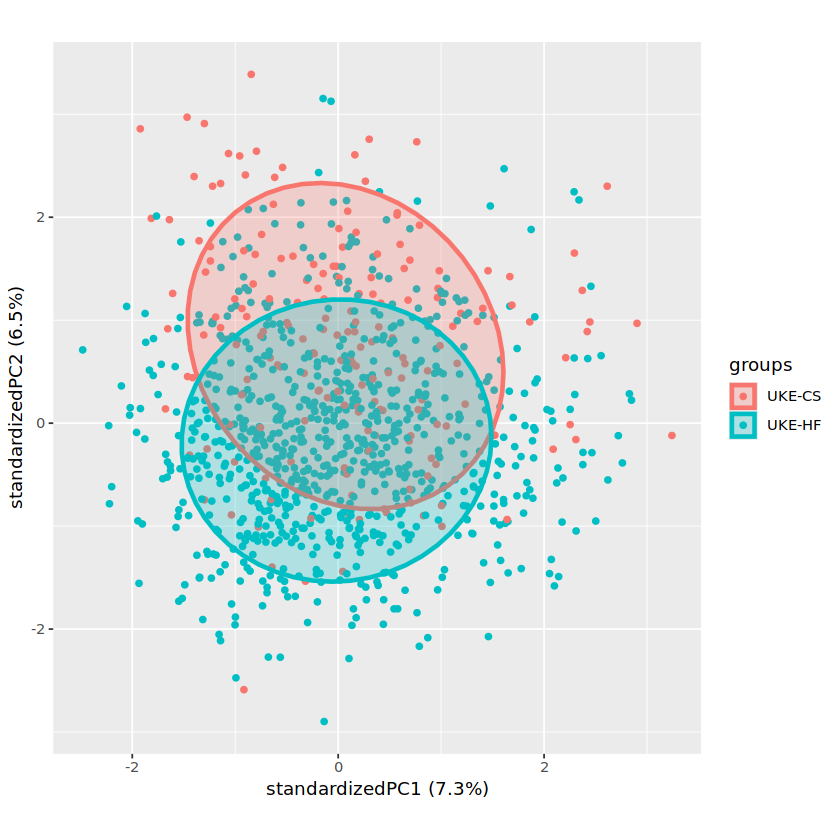

In [50]:
pca_plot <- ggbiplot::ggbiplot(pca_analysis, 
                   groups = dge_filtered$samples$condition, 
                   ellipse = TRUE,
                   var.axes = FALSE)

pca_plot

In [51]:
ggsave("dge_obj_new/pca_plot_50k_reads_filtering.pdf", pca_plot, width = 8, height = 8)

In [52]:
# Create the MDS plot properly with colors and legend
pdf("dge_obj_new/mds_plot_after_filtering_genes_and_normalising_50kreads_filtering.pdf", width = 20, height = 12)

# Create colors based on conditions
color_map <- c("UKE-HF" = "red", "UKE-CS" = "blue")
plotColors <- color_map[dge_filtered$samples$condition]

# Create the MDS plot
plotMDS(normalized_counts_logcpm, 
        col = plotColors,
        main = "MDS Plot of Normalized Counts",
        labels = dge_filtered$samples$sample_ID)

# Add a legend manually
legend("topright", 
       legend = names(color_map),
       fill = color_map,
       title = "Condition",
       bg = "white")

dev.off()

png 
  2

In [53]:
# Create the MDS plot properly with colors and legend
pdf("dge_obj_new/mds_plot_after_filtering_genes_and_normalising_50kreads_filtering_timepoints.pdf", width = 20, height = 12)

# Create colors based on conditions
color_map <- c("UKE-HF" = "red", "UKE-CS" = "blue")
plotColors <- color_map[dge_filtered$samples$condition]

# Create the MDS plot
plotMDS(normalized_counts_logcpm, 
        col = plotColors,
        main = "MDS Plot of Normalized Counts",
        labels = dge_filtered$samples$sample_ID)

# Add a legend manually
legend("topright", 
       legend = names(color_map),
       fill = color_map,
       title = "Condition",
       bg = "white")

dev.off()

png 
  2

In [54]:
# Load required libraries if not already loaded
# library(limma)
# library(edgeR)

# Create a combined factor for condition and time point
dge_filtered$samples$group <- paste(dge_filtered$samples$condition, dge_filtered$samples$tp, sep="_")

# Create a color palette that distinguishes both condition and time point
# First, determine unique combinations
unique_groups <- unique(dge_filtered$samples$group)

# Create a color palette with distinct colors
# You may want to customize these colors based on your preferences
color_palette <- rainbow(length(unique_groups))
names(color_palette) <- unique_groups

# Assign colors to each sample based on the combined group
plotColors <- color_palette[dge_filtered$samples$group]

# Create the PDF with appropriate dimensions
pdf("dge_obj_new/mds_plot_condition_timepoint.pdf", width = 10, height = 8)

# Create MDS plot
plotMDS(dge_filtered, 
        col = plotColors,
        main = "MDS Plot by Condition and Time Point",
        labels = rownames(dge_filtered$samples),
        cex = 0.8)

# Add a legend
legend("topright", 
       legend = unique_groups,
       fill = color_palette,
       title = "Condition_TimePoint",
       cex = 0.7,
       inset = 0.01,
       bg = "white")

dev.off()

# If you want separate MDS plots for condition and time point
# MDS plot by condition only
pdf("dge_obj_new/mds_plot_condition.pdf", width = 10, height = 8)

conditionColors <- ifelse(dge_filtered$samples$condition == "UKE-HF", "red", 
                         ifelse(dge_filtered$samples$condition == "UKE-CS", "light blue", "gray"))

plotMDS(dge_filtered, 
        col = conditionColors,
        main = "MDS Plot by Condition",
        labels = rownames(dge_filtered$samples),
        cex = 0.8)

legend("topright", 
       legend = unique(dge_filtered$samples$condition),
       fill = c("red", "light blue", "gray")[1:length(unique(dge_filtered$samples$condition))],
       title = "Condition",
       cex = 0.7,
       inset = 0.01,
       bg = "white")

dev.off()

# MDS plot by time point only
pdf("dge_obj_new/mds_plot_timepoint.pdf", width = 10, height = 8)

# Create colors based on time point
unique_timepoints <- unique(dge_filtered$samples$tp)
tp_colors <- rainbow(length(unique_timepoints))
names(tp_colors) <- unique_timepoints
timePointColors <- tp_colors[dge_filtered$samples$tp]

plotMDS(dge_filtered, 
        col = timePointColors,
        main = "MDS Plot by Time Point",
        labels = rownames(dge_filtered$samples),
        cex = 0.8)

legend("topright", 
       legend = unique_timepoints,
       fill = tp_colors,
       title = "Time Point",
       cex = 0.7,
       inset = 0.01,
       bg = "white")

dev.off()

# Additional option: MDS plot with shapes for condition and colors for time point
pdf("dge_obj_new/mds_plot_condition_timepoint_shapes.pdf", width = 10, height = 8)

# Create MDS plot with pch (shapes) for condition and colors for time point
condition_shapes <- as.numeric(factor(dge_filtered$samples$condition)) + 15  # Different shapes for conditions

plotMDS(dge_filtered, 
        col = timePointColors,
        pch = condition_shapes,
        main = "MDS Plot (Colors: Time Point, Shapes: Condition)",
        labels = NULL,  # No labels for cleaner plot
        cex = 1.5)  # Larger points

# Add a legend for time points (colors)
legend("topright", 
       legend = unique_timepoints,
       fill = tp_colors,
       title = "Time Point",
       cex = 0.7,
       inset = 0.01,
       bg = "white")

# Add a legend for conditions (shapes)
legend("topleft", 
       legend = unique(dge_filtered$samples$condition),
       pch = as.numeric(factor(unique(dge_filtered$samples$condition))) + 15,
       title = "Condition",
       cex = 0.7,
       inset = 0.01,
       bg = "white")

dev.off()

png 
  2

png 
  2

png 
  2

png 
  2

In [55]:
normalized_counts_logcpm


,LCLC100154,LCLC200028,LCLC200067,LCSC100029,LCLC400339,LCSC100041,LCLC400152,LCLC300141,LCLC200053,LCLC100029,⋯,LCLC200253,LCLC200351,LCLC100254,LCLC200252,LCLC100251,LCLC100252,LCLC100253,LCLC200255,LCLC100256,LCLC300253
TSPAN6,3.583331,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,⋯,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647
DPM1,6.050372,5.393123,5.849808,4.217064,5.577501,4.848232,4.276244,5.270089,5.406982,5.343225,⋯,5.055933,5.657296,5.370332,5.589092,5.542849,5.896099,5.498010,5.576794,5.403368,5.532479
SCYL3,5.015439,5.165361,4.581378,4.660867,3.311573,5.117103,5.068358,2.378647,5.239380,5.512581,⋯,4.127527,4.342672,2.928170,4.202567,3.815156,3.856006,3.887385,3.741904,4.498355,4.284723
FGR,8.663813,7.193330,7.958958,8.351986,7.887964,8.512403,7.767140,8.294791,7.806830,7.094503,⋯,7.333686,8.550303,7.028681,7.453662,7.900383,7.653915,7.983852,7.016971,7.757119,7.944565
CFH,2.378647,2.378647,3.161643,2.378647,2.378647,2.378647,2.378647,2.378647,3.300719,2.378647,⋯,2.797951,2.378647,2.378647,2.378647,3.028385,2.378647,2.378647,2.378647,2.669155,2.804628
FUCA2,3.583331,3.503049,4.581378,2.378647,4.276829,4.848232,3.872950,3.759947,3.858741,2.378647,⋯,3.804327,3.354763,4.108964,4.982917,5.180484,5.102876,4.608610,4.971400,4.827922,2.804628
GCLC,3.583331,4.561446,3.161643,6.974721,3.311573,4.517505,4.591080,3.759947,3.858741,5.151312,⋯,5.055933,4.151760,5.283694,4.202567,5.398535,4.306177,4.944640,5.474358,4.570567,4.999769
NFYA,3.583331,3.503049,3.161643,2.378647,3.311573,3.472688,2.378647,5.270089,3.300719,4.668224,⋯,2.797951,4.662169,3.636143,4.066992,4.424391,3.717484,4.292604,3.553771,4.342091,4.916887
STPG1,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,⋯,2.378647,2.378647,3.325156,2.378647,2.378647,2.378647,2.378647,2.378647,2.910856,2.378647
NIPAL3,2.378647,5.165361,4.039530,3.572789,5.069033,2.378647,3.872950,5.270089,3.858741,5.151312,⋯,4.507212,3.931676,4.108964,3.917341,3.474752,3.856006,3.887385,3.741904,4.639336,3.133082


In [56]:
write.csv(normalized_counts_logcpm, "dge_obj_new/normalised_counts_50k.csv")

In [57]:
saveRDS(normalized_counts_logcpm, "dge_obj_new/normalised_counts_50k.rds")

In [58]:
dge_filtered$genes


,ENSEMBL,external_gene_name.x,description.x
,<chr>,<chr>,<chr>
TSPAN6,ENSG00000000003,TSPAN6,tetraspanin 6 [Source:HGNC Symbol;Acc:HGNC:11858]
DPM1,ENSG00000000419,DPM1,"dolichyl-phosphate mannosyltransferase subunit 1, catalytic [Source:HGNC Symbol;Acc:HGNC:3005]"
SCYL3,ENSG00000000457,SCYL3,SCY1 like pseudokinase 3 [Source:HGNC Symbol;Acc:HGNC:19285]
FGR,ENSG00000000938,FGR,"FGR proto-oncogene, Src family tyrosine kinase [Source:HGNC Symbol;Acc:HGNC:3697]"
CFH,ENSG00000000971,CFH,complement factor H [Source:HGNC Symbol;Acc:HGNC:4883]
FUCA2,ENSG00000001036,FUCA2,alpha-L-fucosidase 2 [Source:HGNC Symbol;Acc:HGNC:4008]
GCLC,ENSG00000001084,GCLC,glutamate-cysteine ligase catalytic subunit [Source:HGNC Symbol;Acc:HGNC:4311]
NFYA,ENSG00000001167,NFYA,nuclear transcription factor Y subunit alpha [Source:HGNC Symbol;Acc:HGNC:7804]
STPG1,ENSG00000001460,STPG1,sperm tail PG-rich repeat containing 1 [Source:HGNC Symbol;Acc:HGNC:28070]


In [59]:
write.csv(as.data.frame(dge_filtered$genes), "dge_obj_new/genes_50k.csv")

In [60]:
normalized_counts_logcpm = t(normalized_counts_logcpm)
head(normalized_counts_logcpm)


,TSPAN6,DPM1,SCYL3,FGR,CFH,FUCA2,GCLC,NFYA,STPG1,NIPAL3,⋯,ACTL10,PANO1,PRRC2B,F8A1,BMS1P14,HOMEZ,ZNF781,CCDC144NL,TRIM16L,SOD2
LCLC100154,3.583331,6.050372,5.015439,8.663813,2.378647,3.583331,3.583331,3.583331,2.378647,2.378647,⋯,3.583331,2.378647,5.015439,5.520931,2.378647,2.378647,2.378647,2.378647,2.378647,9.150850
LCLC200028,2.378647,5.393123,5.165361,7.193330,2.378647,3.503049,4.561446,3.503049,2.378647,5.165361,⋯,2.378647,2.378647,4.894775,4.561446,2.378647,3.503049,2.378647,2.378647,2.378647,8.881495
LCLC200067,2.378647,5.849808,4.581378,7.958958,3.161643,4.581378,3.161643,3.161643,2.378647,4.039530,⋯,3.666356,2.378647,5.136865,4.039530,2.378647,4.039530,4.039530,2.378647,2.378647,9.760285
LCSC100029,2.378647,4.217064,4.660867,8.351986,2.378647,2.378647,6.974721,2.378647,2.378647,3.572789,⋯,2.378647,2.378647,3.572789,4.217064,2.378647,3.572789,2.378647,2.378647,2.378647,10.342125
LCLC400339,2.378647,5.577501,3.311573,7.887964,2.378647,4.276829,3.311573,3.311573,2.378647,5.069033,⋯,2.378647,2.378647,5.577501,4.276829,2.378647,3.311573,2.378647,2.378647,2.378647,8.528477
LCSC100041,2.378647,4.848232,5.117103,8.512403,2.378647,4.848232,4.517505,3.472688,2.378647,2.378647,⋯,2.378647,2.378647,4.087683,2.378647,2.378647,2.378647,2.378647,2.378647,2.378647,10.448993


In [61]:
write.csv(normalized_counts_logcpm, "/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/input_data/log_normalised_bulk_seq_uke.csv")